# **Train Graph Neural Networks with AUPRC Loss**

**Author**: Gang Li, Tianbao Yang



**Introduction**

In this tutorial, you will learn how to quickly train a GNN
model by optimizing **AUPRC**  with our novel `APLoss` and `SOAP` optimizer
[[ref]](https://arxiv.org/abs/2104.08736) on a binary molecule
classification task from *ogbg-molpcba* dataset. After completion of this
tutorial, you should be able to use LibAUC to train your own models
on your own datasets.

**Reference**:

If you find this tutorial helpful,  please acknowledge our library and cite the following papers:
```
@inproceedings{yuan2023libauc,
  title={LibAUC: A Deep Learning Library for X-Risk Optimization},
  author={Zhuoning Yuan and Dixian Zhu and Zi-Hao Qiu and Gang Li and Xuanhui Wang and Tianbao Yang},
  booktitle={29th SIGKDD Conference on Knowledge Discovery and Data Mining},
  year={2023}
}

@article{qi2021stochastic,
  title={Stochastic Optimization of Areas Under Precision-Recall Curves with Provable Convergence},
  author={Qi, Qi and Luo, Youzhi and Xu, Zhao and Ji, Shuiwang and Yang, Tianbao},
  journal={Advances in Neural Information Processing Systems},
  volume={34},
  year={2021}
}
```

# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [ ]:
from libauc.losses import APLoss
from libauc.optimizers import SOAP
from libauc.models import GCN, DeeperGCN, GIN, GINE, GAT, MPNN, GraphSAGE, PNA
from libauc.sampler import DualSampler
from libauc.metrics import auc_prc_score

from ogb.graphproppred import PygGraphPropPredDataset
import torch
import torch_geometric
import numpy as np
import pandas as pd
import os


# **Reproducibility**

The following function `set_all_seeds` limits the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [ ]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(2023)

# **Loading datasets**

   Now, we define the data input pipeline. We inherit the `PygGraphPropPredDataset` class from `ogb` package since we are going to work on *ogbg-molpcba* dataset.


In [ ]:
class GraphDataset(PygGraphPropPredDataset):
    def __getitem__(self, idx):
        if isinstance(idx, (int,np.int64)):
            item = self.get(self.indices()[idx])
            item.idx = torch.LongTensor([idx])
            return item
        else:
            return self.index_select(idx)

   For simplicity of exposition, we work on the first task from *ogbg-molpcba* dataset.

In [ ]:

dataset = GraphDataset(name = 'ogbg-molpcba')
labels = pd.read_csv(os.path.join('./dataset/ogbg_molpcba/raw', 'graph-label.csv.gz'),
                        compression='gzip', header = None).values

#### get the official train_val_test split
split_idx = dataset.get_idx_split()
#### get training lable for task_0
train_labels = labels[split_idx["train"]][:,0]

#### remove samples which have 'nan' as their labels
not_nan = ~np.isnan(train_labels)
train_labels = train_labels[not_nan]
train_dataset = dataset[split_idx["train"]][not_nan]
test_dataset = dataset[split_idx["test"]][~np.isnan(labels[split_idx["test"]][:,0] )]


# **Configuration**

In [ ]:
# Hyper-Parameters
batch_size = 64
lr = 1e-3
margin = 0.6
gamma = 0.1
weight_decay = 1e-5
total_epoch = 60
decay_epoch = [30, 45]
load_pretrain = False
with_edge_features = True

# **Pretraining (Recommended)**

Following the original [paper](https://arxiv.org/abs/2104.08736), it's recommended to start from a pretrained checkpoint with cross-entropy loss to significantly boost models' performance. It includes a pre-training step with standard cross-entropy loss, and an AUPRC maximization step that maximizes an AUPRC surrogate loss of the pre-trained model.

In [ ]:
from torch.optim import Adam
import warnings
warnings.filterwarnings('ignore')

load_pretrain = True

### ************ model selection BEGIN***************#############

##### without edge feature
# model = GCN(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GIN(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GraphSAGE(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.2, jk = "last", norm='BatchNorm')

##### with edge feature
# model = DeeperGCN(emb_dim=300, num_tasks= 1, num_layers = 14, t=0.1, learn_t=True, dropout=0.0, norm='BatchNorm')
model = GINE(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GAT(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.0, jk = "last",act='elu',norm='BatchNorm',v2=False, heads=6)
# model = GAT(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.0, jk = "last",act='elu', norm='BatchNorm',v2=True, heads=6)
# model = MPNN(emb_dim=100, num_tasks= 1,num_layers = 3, dropout=0.2, jk = "last", norm='BatchNorm')
# #    for PNA
# # Compute the maximum in-degree in the training data.
# from torch_geometric.utils import degree
# max_degree = -1
# for data in train_dataset:
#     d = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
#     max_degree = max(max_degree, int(d.max()))
# # Compute the in-degree histogram tensor
# deg = torch.zeros(max_degree + 1, dtype=torch.long)
# for data in train_dataset:
#     d = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
#     deg += torch.bincount(d, minlength=deg.numel())
# model = PNA(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.2, jk = "last", norm='BatchNorm', towers=5, deg=deg)

### ************ model selection  END***************#############

model = model.cuda()

loss_fn = torch.nn.BCELoss()
optimizer =Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

trainloader = torch_geometric.loader.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch_geometric.loader.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


best_test = 0
for epoch in range(total_epoch):
    if epoch in decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.1 * param_group['lr']

    model.train()
    for step, batch in enumerate(trainloader):
        batch = batch.cuda()
        if with_edge_features:        #### for DeeperGCN, GINE, GAT, MPNN
            pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)  )
        else:                         #### for GCN, GIN, GraphSAGE
            pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.batch)  )

        loss = loss_fn(pred, batch.y[:,0].reshape(-1,1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for step, batch in enumerate(testloader):
            batch = batch.cuda()
            if with_edge_features:        #### for DeeperGCN, GINE, GAT, MPNN
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)  )
            else:                         #### for GCN, GIN, GraphSAGE
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.batch)  )

            test_pred_list.append(pred.cpu().detach().numpy())
            test_true_list.append(batch.y[:,0].cpu().detach().numpy())

    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_ap = auc_prc_score(test_true, test_pred)
    if best_test < test_ap:
        best_test = test_ap
        torch.save(model.state_dict(), 'ce_pretrained_model_soap_mol.pth')

    model.train()
    print("epoch: %s, test_ap: %.4f, best_test_ap: %.4f, lr: %.4f"%(epoch, test_ap, best_test, optimizer.param_groups[0]['lr'] ))

epoch: 0, test_ap: 0.2096, best_test_ap: 0.2096, lr: 0.0010
epoch: 1, test_ap: 0.2193, best_test_ap: 0.2193, lr: 0.0010
epoch: 2, test_ap: 0.2327, best_test_ap: 0.2327, lr: 0.0010
epoch: 3, test_ap: 0.2550, best_test_ap: 0.2550, lr: 0.0010
epoch: 4, test_ap: 0.2570, best_test_ap: 0.2570, lr: 0.0010
epoch: 5, test_ap: 0.2581, best_test_ap: 0.2581, lr: 0.0010
epoch: 6, test_ap: 0.2696, best_test_ap: 0.2696, lr: 0.0010
epoch: 7, test_ap: 0.2824, best_test_ap: 0.2824, lr: 0.0010
epoch: 8, test_ap: 0.2865, best_test_ap: 0.2865, lr: 0.0010
epoch: 9, test_ap: 0.2963, best_test_ap: 0.2963, lr: 0.0010
epoch: 10, test_ap: 0.2955, best_test_ap: 0.2963, lr: 0.0010
epoch: 11, test_ap: 0.2883, best_test_ap: 0.2963, lr: 0.0010
epoch: 12, test_ap: 0.3053, best_test_ap: 0.3053, lr: 0.0010
epoch: 13, test_ap: 0.3117, best_test_ap: 0.3117, lr: 0.0010
epoch: 14, test_ap: 0.3152, best_test_ap: 0.3152, lr: 0.0010
epoch: 15, test_ap: 0.3192, best_test_ap: 0.3192, lr: 0.0010
epoch: 16, test_ap: 0.3112, best_t

# **Optimizing AUPRC Loss**

   We define ``dataset``, ``DualSampler`` and ``dataloader`` here. By
   default, we use ``batch_size`` 64 and we oversample the minority
   class with ``pos:neg=1:1`` by setting ``sampling_rate=0.5``.

In [ ]:
sampling_rate = 0.5

sampler = DualSampler(None, batch_size, labels=train_labels, sampling_rate=sampling_rate)
trainloader = torch_geometric.loader.DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
trainloader_eval = torch_geometric.loader.DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = torch_geometric.loader.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers = 2)

# **Model, Loss and Optimizer**

In [ ]:
### ************ model selection BEGIN***************#############

##### without edge feature
# model = GCN(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GIN(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GraphSAGE(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.2, jk = "last", norm='BatchNorm')

##### with edge feature
# model = DeeperGCN(emb_dim=300, num_tasks= 1, num_layers = 14, t=0.1, learn_t=True, dropout=0.0, norm='BatchNorm')
model = GINE(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.5, jk = "last", norm='BatchNorm')
# model = GAT(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.0, jk = "last",act='elu',norm='BatchNorm',v2=False, heads=6)
# model = GAT(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.0, jk = "last",act='elu', norm='BatchNorm',v2=True, heads=6)
# model = MPNN(emb_dim=100, num_tasks= 1,num_layers = 3, dropout=0.2, jk = "last", norm='BatchNorm')

# #    for PNA
# # Compute the maximum in-degree in the training data.
# from torch_geometric.utils import degree
# max_degree = -1
# for data in train_dataset:
#     d = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
#     max_degree = max(max_degree, int(d.max()))
# # Compute the in-degree histogram tensor
# deg = torch.zeros(max_degree + 1, dtype=torch.long)
# for data in train_dataset:
#     d = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
#     deg += torch.bincount(d, minlength=deg.numel())
# model = PNA(emb_dim=300, num_tasks= 1,num_layers = 5, dropout=0.2, jk = "last", norm='BatchNorm', towers=5, deg=deg)

### ************ model selection  END***************#############

model = model.cuda()
# load pretrained model
if load_pretrain:
    PATH = 'ce_pretrained_model_soap_mol.pth'
    state_dict = torch.load(PATH)
    filtered = {k:v for k,v in state_dict.items() if 'graph_pred_linear' not in k}
    msg = model.load_state_dict(filtered, False)
    print(msg)
    model.graph_pred_linear.reset_parameters()

loss_fn = APLoss(len(train_dataset), margin=margin, gamma=gamma)
optimizer = SOAP(model.parameters(), lr=lr, mode='adam', weight_decay=weight_decay)

_IncompatibleKeys(missing_keys=['graph_pred_linear.weight', 'graph_pred_linear.bias'], unexpected_keys=[])


# **Training**

In [ ]:
print ('Start Training')
print ('-'*30)

train_log, test_log = [], []
best_test = 0
for epoch in range(total_epoch):
    if epoch in decay_epoch:
        optimizer.update_lr(decay_factor=10)

    model.train()
    for step, batch in enumerate(trainloader):
        batch = batch.cuda()
        if with_edge_features:        #### for DeeperGCN, GINE, GAT, MPNN
            pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)  )
        else:                         #### for GCN, GIN, GraphSAGE
            pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.batch)  )
        loss = loss_fn(pred, batch.y[:,0], batch.idx)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on training sets
    model.eval()
    train_pred_list, train_true_list = [], []
    with torch.no_grad():
        for step, batch in enumerate(trainloader_eval):
            batch = batch.cuda()
            if with_edge_features:        #### for DeeperGCN, GINE, GAT, MPNN
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)  )
            else:                         #### for GCN, GIN, GraphSAGE
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.batch)  )

            train_pred_list.append(pred.cpu().detach().numpy())
            train_true_list.append(batch.y[:,0].cpu().detach().numpy())
    train_true = np.concatenate(train_true_list)
    train_pred = np.concatenate(train_pred_list)

    train_ap = auc_prc_score(train_true, train_pred)
    train_log.append(train_ap)

    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for step, batch in enumerate(testloader):
            batch = batch.cuda()
            if with_edge_features:        #### for DeeperGCN, GINE, GAT, MPNN
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)  )
            else:                         #### for GCN, GIN, GraphSAGE
                pred = torch.sigmoid( model(batch.x, batch.edge_index, batch.batch)  )

            test_pred_list.append(pred.cpu().detach().numpy())
            test_true_list.append(batch.y[:,0].cpu().detach().numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_ap = auc_prc_score(test_true, test_pred)
    test_log.append(test_ap)
    if best_test < test_ap:
        best_test = test_ap

    model.train()
    print("epoch: %s, train_ap: %.4f, test_ap: %.4f, best_test_ap: %.4f, lr: %.4f"%(epoch, train_ap, test_ap, best_test, optimizer.lr ))

Start Training
------------------------------
epoch: 0, train_ap: 0.4517, test_ap: 0.3509, best_test_ap: 0.3509, lr: 0.0010
epoch: 1, train_ap: 0.4449, test_ap: 0.3546, best_test_ap: 0.3546, lr: 0.0010
epoch: 2, train_ap: 0.4442, test_ap: 0.3466, best_test_ap: 0.3546, lr: 0.0010
epoch: 3, train_ap: 0.4362, test_ap: 0.3510, best_test_ap: 0.3546, lr: 0.0010
epoch: 4, train_ap: 0.4495, test_ap: 0.3515, best_test_ap: 0.3546, lr: 0.0010
epoch: 5, train_ap: 0.4527, test_ap: 0.3613, best_test_ap: 0.3613, lr: 0.0010
epoch: 6, train_ap: 0.4581, test_ap: 0.3566, best_test_ap: 0.3613, lr: 0.0010
epoch: 7, train_ap: 0.4514, test_ap: 0.3581, best_test_ap: 0.3613, lr: 0.0010
epoch: 8, train_ap: 0.4555, test_ap: 0.3559, best_test_ap: 0.3613, lr: 0.0010
epoch: 9, train_ap: 0.4515, test_ap: 0.3535, best_test_ap: 0.3613, lr: 0.0010
epoch: 10, train_ap: 0.4632, test_ap: 0.3620, best_test_ap: 0.3620, lr: 0.0010
epoch: 11, train_ap: 0.4659, test_ap: 0.3693, best_test_ap: 0.3693, lr: 0.0010
epoch: 12, train

# **Visualization**

Now, let's see the learning curve for optimizing AUPRC on train and test sets.

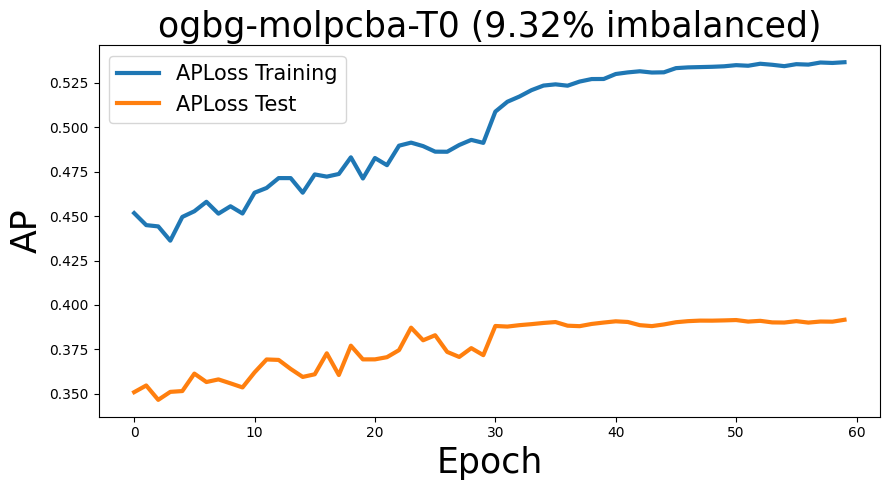

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='APLoss Training', linewidth=3)
plt.plot(x, test_log,  linestyle='-', label='APLoss Test', linewidth=3)
plt.title('ogbg-molpcba-T0 (9.32% imbalanced)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AP', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

plt.tight_layout()
plt.savefig('ap_gnn.png')
plt.show()